Project Deliverable #5: Models

This following code loads our dataset and shows the first 5 rows.

In [1]:
import pandas as pd

# Load my dataset
df = pd.read_csv("Firefox_bugs.csv")

# See the first few rows
df.head()


,Summary,Issue id,Status,Priority,Resolution,Created,Resolved,Description
0,Address bar doesn't elide origins correctly,1606532,RESOLVED,--,DUPLICATE,2020-01-01 05:10:54+00:00,2023-06-06 00:44:25+00:00,User Agent: Mozilla/5.0 (Windows NT 10.0; Win6...
1,"""TypeError: info.PDFFormatVersion is undefined...",1606566,VERIFIED,--,FIXED,2020-01-01 18:26:12+00:00,2020-02-06 10:01:56+00:00,When the PDF version cannot be extracted from ...
2,no suggestions while typing in urlbar,1606572,RESOLVED,--,WORKSFORME,2020-01-01 22:21:53+00:00,2020-01-14 13:08:25+00:00,User Agent: Mozilla/5.0 (X11; Linux x86_64; rv...
3,File association Remote Code Execution via com...,1606596,RESOLVED,--,FIXED,2020-01-02 07:54:43+00:00,2024-05-30 17:06:02+00:00,Tested on Microsoft Windows 10 Enterprise vers...
4,login button on faq page is not working,1606602,RESOLVED,--,INCOMPLETE,2020-01-02 10:11:03+00:00,2023-07-30 20:18:55+00:00,User Agent: Mozilla/5.0 (Windows NT 6.1; Win64...


The following code counts the number of duplicate rows.

In [2]:
# Count total duplicate rows
num_dupes = df.duplicated().sum()
print(f"Number of duplicate rows: {num_dupes}")

Number of duplicate rows: 0


Since it showed no duplicates, we specified that the check for duplicated be based on duplicated summary and descriptions. 62 Rows were found.

In [3]:
df[df.duplicated(subset=["Summary", "Description"])]

,Summary,Issue id,Status,Priority,Resolution,Created,Resolved,Description
2894,Perma browser_oneOffs_contextMenu.js | Test ti...,1651979,RESOLVED,--,DUPLICATE,2020-07-10 12:34:25+00:00,2020-07-22 20:41:37+00:00,[Tracking Requested - why for this release]:\n...
3073,Interface elements do not working sometimes af...,1654772,RESOLVED,--,DUPLICATE,2020-07-23 11:26:05+00:00,2020-07-28 20:47:16+00:00,User Agent: Mozilla/5.0 (Macintosh; Intel Mac ...
3863,Firefox ESR auto-update 68.12 -> 78 fail,1666791,RESOLVED,--,INVALID,2020-09-23 14:10:48+00:00,2020-09-23 16:45:33+00:00,User Agent: Mozilla/5.0 (Windows NT 6.1; Win64...
5784,can not search in chrome://browser/content/bro...,1692713,RESOLVED,--,DUPLICATE,2021-02-13 21:41:59+00:00,2021-02-13 21:43:25+00:00,User Agent: Mozilla/5.0 (Windows NT 10.0; Win6...
6084,Intermittent browser/components/privatebrowsin...,1696274,RESOLVED,P5,DUPLICATE,2021-03-03 21:37:41+00:00,2021-03-03 21:38:17+00:00,**Filed by:** abutkovits [at] mozilla.com\n**P...
...,...,...,...,...,...,...,...,...
23751,Intermittent browser/components/asrouter/tests...,1936842,RESOLVED,--,DUPLICATE,2024-12-12 15:58:29+00:00,2024-12-12 15:59:00+00:00,**Filed by:** sstanca [at] mozilla.com\n**Pars...
23969,Arbitrary Javascript injection in PDF.js throu...,1939692,VERIFIED,--,DUPLICATE,2025-01-02 08:50:15+00:00,2025-01-03 02:18:26+00:00,(Tested with Firefox 124.0b9 on Ubuntu and wit...
24294,severe browser lags and high CPU and RAM usage,1945048,RESOLVED,--,INCOMPLETE,2025-01-31 08:41:40+00:00,2025-03-04 07:07:16+00:00,User Agent: Mozilla/5.0 (Windows NT 10.0; Win6...
24385,Intermittent browser/components/messagepreview...,1946380,NEW,P1,NaN,2025-02-06 11:04:04+00:00,2025-03-03 06:34:31+00:00,**Filed by:** agoloman [at] mozilla.com\n**Par...


This code removes all the duplicates found.

In [4]:
# Remove all duplicate rows based on summary and description, if found
df = df.drop_duplicates(subset=["Summary", "Description"])

In [5]:
df[df.duplicated(subset=["Summary", "Description"])]

,Summary,Issue id,Status,Priority,Resolution,Created,Resolved,Description


The next two code excertps installs packages we need to complete our data pre-processing tasks

In [6]:
%pip install nltk

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 791.7/791.7 kB 70.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [7]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

In [8]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


The code encodes the status and resolution fields and shows results in the first few rows.
We use oneHotEncoder for the resolution and status field because order doesnt matter.

In [9]:
from sklearn.preprocessing import OneHotEncoder


ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

encodCol = ohe.fit_transform(df[["Status", "Resolution"]])

df_encoded = pd.concat([
    df.reset_index(drop=True),
    pd.DataFrame(encodCol.astype(int), columns=ohe.get_feature_names_out(["Status", "Resolution"]))
], axis=1)

df_encoded.head()

,Summary,Issue id,Status,Priority,Resolution,Created,Resolved,Description,Status_ASSIGNED,Status_NEW,...,Status_VERIFIED,Resolution_DUPLICATE,Resolution_FIXED,Resolution_INACTIVE,Resolution_INCOMPLETE,Resolution_INVALID,Resolution_MOVED,Resolution_WONTFIX,Resolution_WORKSFORME,Resolution_nan
0,Address bar doesn't elide origins correctly,1606532,RESOLVED,--,DUPLICATE,2020-01-01 05:10:54+00:00,2023-06-06 00:44:25+00:00,User Agent: Mozilla/5.0 (Windows NT 10.0; Win6...,0,0,...,0,1,0,0,0,0,0,0,0,0
1,"""TypeError: info.PDFFormatVersion is undefined...",1606566,VERIFIED,--,FIXED,2020-01-01 18:26:12+00:00,2020-02-06 10:01:56+00:00,When the PDF version cannot be extracted from ...,0,0,...,1,0,1,0,0,0,0,0,0,0
2,no suggestions while typing in urlbar,1606572,RESOLVED,--,WORKSFORME,2020-01-01 22:21:53+00:00,2020-01-14 13:08:25+00:00,User Agent: Mozilla/5.0 (X11; Linux x86_64; rv...,0,0,...,0,0,0,0,0,0,0,0,1,0
3,File association Remote Code Execution via com...,1606596,RESOLVED,--,FIXED,2020-01-02 07:54:43+00:00,2024-05-30 17:06:02+00:00,Tested on Microsoft Windows 10 Enterprise vers...,0,0,...,0,0,1,0,0,0,0,0,0,0
4,login button on faq page is not working,1606602,RESOLVED,--,INCOMPLETE,2020-01-02 10:11:03+00:00,2023-07-30 20:18:55+00:00,User Agent: Mozilla/5.0 (Windows NT 6.1; Win64...,0,0,...,0,0,0,0,1,0,0,0,0,0


This next couple excerpts of code sets the ordinal order for the priority field with P5 being
the most critical, encodes it and show results in the first couple rows
We dont use a label encoder because it will order alphabetically and in this case P5 is lowest priority
so we need to map the order manually to make sure it is right.
We use pd.Categorical which is an ordinal encoder that preserves both label and order.

In [10]:
priority_order = ["P5","P4","P3","P2","P1"]  #lowest → highest
priority_map = {p:i for i,p in enumerate(priority_order)}

df["Priority_encoded"] = df["Priority"].map(priority_map)

unmapped = df.loc[df["Priority_encoded"].isna(), "Priority"].unique()
print("Unmapped values:", unmapped)

Unmapped values: ['--']


In [11]:
df["Priority_cat"] = pd.Categorical(df["Priority"], categories=priority_order, ordered=True)

In [12]:
df[["Priority","Priority_encoded"]].head(10)

# check to make sure it worked
print(df["Priority_cat"].value_counts().sort_index())

Priority_cat
P5    4642
P4      57
P3    3787
P2    1822
P1    2323
Name: count, dtype: int64


In [13]:
df[["Priority", "Priority_cat", "Priority_encoded"]].head(10)

,Priority,Priority_cat,Priority_encoded
0,--,NaN,NaN
1,--,NaN,NaN
2,--,NaN,NaN
3,--,NaN,NaN
4,--,NaN,NaN
5,--,NaN,NaN
6,--,NaN,NaN
7,P3,P3,2.0
8,P5,P5,0.0
9,P5,P5,0.0


In [14]:
df.head(10)

,Summary,Issue id,Status,Priority,Resolution,Created,Resolved,Description,Priority_encoded,Priority_cat
0,Address bar doesn't elide origins correctly,1606532,RESOLVED,--,DUPLICATE,2020-01-01 05:10:54+00:00,2023-06-06 00:44:25+00:00,User Agent: Mozilla/5.0 (Windows NT 10.0; Win6...,NaN,NaN
1,"""TypeError: info.PDFFormatVersion is undefined...",1606566,VERIFIED,--,FIXED,2020-01-01 18:26:12+00:00,2020-02-06 10:01:56+00:00,When the PDF version cannot be extracted from ...,NaN,NaN
2,no suggestions while typing in urlbar,1606572,RESOLVED,--,WORKSFORME,2020-01-01 22:21:53+00:00,2020-01-14 13:08:25+00:00,User Agent: Mozilla/5.0 (X11; Linux x86_64; rv...,NaN,NaN
3,File association Remote Code Execution via com...,1606596,RESOLVED,--,FIXED,2020-01-02 07:54:43+00:00,2024-05-30 17:06:02+00:00,Tested on Microsoft Windows 10 Enterprise vers...,NaN,NaN
4,login button on faq page is not working,1606602,RESOLVED,--,INCOMPLETE,2020-01-02 10:11:03+00:00,2023-07-30 20:18:55+00:00,User Agent: Mozilla/5.0 (Windows NT 6.1; Win64...,NaN,NaN
5,dropdown list in search menu does not appear,1606605,RESOLVED,--,INCOMPLETE,2020-01-02 10:45:21+00:00,2020-02-13 16:04:38+00:00,User Agent: Mozilla/5.0 (Windows NT 6.1; Win64...,NaN,NaN
6,right click context menu displaying in first s...,1606620,NEW,--,NaN,2020-01-02 12:46:36+00:00,2023-01-23 19:19:13+00:00,User Agent: Mozilla/5.0 (Macintosh; Intel Mac ...,NaN,NaN
7,Inefficient z-ordering of elements in the brow...,1606631,RESOLVED,P3,INCOMPLETE,2020-01-02 13:46:45+00:00,2024-06-28 09:36:11+00:00,Steps to reproduce:\n 1. Be on macOS.\n 2. Ena...,2.0,P3
8,pages with unsaved data should not be closed b...,1606644,NEW,P5,NaN,2020-01-02 14:46:03+00:00,2023-03-13 14:15:22+00:00,User Agent: Mozilla/5.0 (X11; Ubuntu; Linux x8...,0.0,P5
9,Intermittent browser/components/enterprisepoli...,1606648,RESOLVED,P5,INCOMPLETE,2020-01-02 14:57:57+00:00,2020-08-25 17:01:57+00:00,**Filed by:** nbeleuzu [at] mozilla.com\n**Par...,0.0,P5


This code creates a function to process raw text by removing special characters, transforming to lowercase, tokenizing, stemming and removing stop words

In [15]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

EN_STOP = set(stopwords.words('english'))
STEMMER = PorterStemmer()

def preprocess_text(text: str):
    if not isinstance(text, str):
        text = "" if pd.isna(text) else str(text)

    #remove special characters
    text = re.sub(r'[^A-Za-z0-9\s]', ' ', text)

    #Collapse multiple spaces if exists
    text = re.sub(r'\s+', ' ', text).strip()

    #lowercase
    text = text.lower()

    #tokenize
    tokens = word_tokenize(text)

    #remove stop words
    tokens = [t for t in tokens if t not in EN_STOP]

    #stemming
    tokens = [STEMMER.stem(t) for t in tokens]

    return tokens

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/kmumenin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/kmumenin/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/kmumenin/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


This code concatentes the text and description field into one column and displays the new column

In [16]:
# 3) Create the combined Text column
df["Summary"] = df["Summary"].fillna("").astype(str)
df["Description"] = df["Description"].fillna("").astype(str)
df["Text"] = (df["Summary"] + " " + df["Description"]).str.replace(r"\s+", " ", regex=True).str.strip()

# 4) Check to see if it worked
print("New column created:", "Text" in df.columns)
print(df[["Summary", "Description", "Text"]].head(5))

New column created: True
                                             Summary  \
0        Address bar doesn't elide origins correctly   
1  "TypeError: info.PDFFormatVersion is undefined...   
2              no suggestions while typing in urlbar   
3  File association Remote Code Execution via com...   
4            login button on faq page is not working   

                                         Description  \
0  User Agent: Mozilla/5.0 (Windows NT 10.0; Win6...   
1  When the PDF version cannot be extracted from ...   
2  User Agent: Mozilla/5.0 (X11; Linux x86_64; rv...   
3  Tested on Microsoft Windows 10 Enterprise vers...   
4  User Agent: Mozilla/5.0 (Windows NT 6.1; Win64...   

                                                Text  
0  Address bar doesn't elide origins correctly Us...  
1  "TypeError: info.PDFFormatVersion is undefined...  
2  no suggestions while typing in urlbar User Age...  
3  File association Remote Code Execution via com...  
4  login button on faq pag

This code applies our preprocessing function to the newly created column and returns a column with processed tokens.


In [17]:
#Apply tokenization column
df["processed_tokens"] = df["Text"].apply(preprocess_text)
df["processed_text"]  = df["processed_tokens"].apply(lambda toks: " ".join(toks))

#Make sure it worked
df[["Text", "processed_tokens"]].head(5)

,Text,processed_tokens
0,Address bar doesn't elide origins correctly Us...,"[address, bar, elid, origin, correctli, user, ..."
1,"""TypeError: info.PDFFormatVersion is undefined...","[typeerror, info, pdfformatvers, undefin, pdf,..."
2,no suggestions while typing in urlbar User Age...,"[suggest, type, urlbar, user, agent, mozilla, ..."
3,File association Remote Code Execution via com...,"[file, associ, remot, code, execut, via, comma..."
4,login button on faq page is not working User A...,"[login, button, faq, page, work, user, agent, ..."


Since some of the column have NaN values in their priority columns, we would split it up and use those with values for training and testing the model, while those whithout labels can be used for prediction


In [18]:
#len(df)
labeled_df = df[df["Priority"].isin(["P1", "P2", "P3", "P4", "P5"])].copy()
unlabeled_df = df[~df["Priority"].isin(["P1", "P2", "P3", "P4", "P5"])].copy()

print(labeled_df.shape[0])
print(unlabeled_df.shape[0])



12631
12131


For Resolution cells that contain missing values:

In [19]:
df["Resolution"] = df["Resolution"].fillna("Missing")

Split the labeled data into training and testing

In [20]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    labeled_df,
    test_size=0.2,
    random_state=42,
    stratify=labeled_df["Priority_encoded"]
)

print("Train size:", len(train_df), "Test size:", len(test_df))
print("Train label counts:\n", train_df["Priority_encoded"].value_counts().sort_index())
print("Test label counts:\n", test_df["Priority_encoded"].value_counts().sort_index())

Train size: 10104 Test size: 2527
Train label counts:
 Priority_encoded
0.0    3713
1.0      46
2.0    3029
3.0    1458
4.0    1858
Name: count, dtype: int64
Test label counts:
 Priority_encoded
0.0    929
1.0     11
2.0    758
3.0    364
4.0    465
Name: count, dtype: int64


We need a reusable object that:

*  Stores all texts and labels
*  Tokenizes on-demand when the DataLoader asks for an item





In [21]:
from torch.utils.data import Dataset

class BugPriorityDataset(Dataset):
  def __init__(self, df, text_col, label_col, tokenizer, max_len=128):
    self.texts = df[text_col].tolist()
    self.labels = df[label_col].tolist()
    self.tokenizer = tokenizer
    self.max_len = max_len

  def __len__(self):
    return len(self.texts)

  def __getitem__(self, idx):
    text = self.texts[idx]
    label = self.labels[idx]

    encoded = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=self.max_len,
        return_tensors = "pt"
        )
    item_dict = {
      "input_ids": encoded["input_ids"].squeeze(0),
      "attention_mask": encoded["attention_mask"].squeeze(0),
      "labels": torch.tensor(label, dtype=torch.long)
    }

    return item_dict


In [24]:
!pip install transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 59.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 60.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 58.5 MB/s eta 0:00:00


Design the training and test dataset

In [25]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
train_dataset = BugPriorityDataset(train_df, "Text", "Priority_encoded", tokenizer)
test_dataset = BugPriorityDataset(test_df, "Text", "Priority_encoded", tokenizer)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Turn the dataset into dataloader for the model

In [26]:
from torch.utils.data import DataLoader

BATCH_SIZE = 16
train_batch = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_batch = DataLoader(test_dataset, batch_size=BATCH_SIZE)


In [28]:
# Setup Features & Labels

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report

# Use the processed text and encoded priority
X_train = train_df["processed_text"]
X_test = test_df["processed_text"]
y_train = train_df["Priority_encoded"]
y_test = test_df["Priority_encoded"]

# TF-IDF vectorization
tfidf = TfidfVectorizer(
    max_features=10000,   # cap vocabulary size
    ngram_range=(1, 2),   # unigrams + bigrams
    min_df=2              # ignore extremely rare terms
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF shapes:", X_train_tfidf.shape, X_test_tfidf.shape)

TF-IDF shapes: (10104, 10000) (2527, 10000)


MODEL: SVM (Support Vector Machine)

In [30]:
from sklearn.svm import LinearSVC

svm_clf = LinearSVC()
svm_clf.fit(X_train_tfidf, y_train)

svm_preds = svm_clf.predict(X_test_tfidf)

print("=== SVM (LinearSVC) Results ===")
print("Accuracy:", accuracy_score(y_test, svm_preds))
print(classification_report(y_test, svm_preds))

=== SVM (LinearSVC) Results ===
Accuracy: 0.6359319351009102
              precision    recall  f1-score   support

         0.0       0.92      0.88      0.90       929
         1.0       0.00      0.00      0.00        11
         2.0       0.54      0.63      0.58       758
         3.0       0.30      0.22      0.26       364
         4.0       0.47      0.49      0.48       465

    accuracy                           0.64      2527
   macro avg       0.45      0.44      0.44      2527
weighted avg       0.63      0.64      0.63      2527



/home/kmumenin/anaconda3/envs/obj/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/kmumenin/anaconda3/envs/obj/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/kmumenin/anaconda3/envs/obj/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

MODEL: NAIVE BAYES

In [31]:
from sklearn.naive_bayes import MultinomialNB

nb_clf = MultinomialNB()
nb_clf.fit(X_train_tfidf, y_train)

nb_preds = nb_clf.predict(X_test_tfidf)

print("=== Naive Bayes Results ===")
print("Accuracy:", accuracy_score(y_test, nb_preds))
print(classification_report(y_test, nb_preds))

=== Naive Bayes Results ===
Accuracy: 0.6493866244558766
              precision    recall  f1-score   support

         0.0       0.93      0.88      0.91       929
         1.0       0.00      0.00      0.00        11
         2.0       0.48      0.91      0.63       758
         3.0       0.43      0.01      0.02       364
         4.0       0.61      0.27      0.38       465

    accuracy                           0.65      2527
   macro avg       0.49      0.42      0.39      2527
weighted avg       0.66      0.65      0.59      2527



/home/kmumenin/anaconda3/envs/obj/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/kmumenin/anaconda3/envs/obj/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/kmumenin/anaconda3/envs/obj/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

MODEL: SG BOOST

In [33]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(
    objective="multi:softmax",
    num_class=5,          # priorities P1–P5
    eval_metric="mlogloss",
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist"    # faster on most machines
)

xgb_clf.fit(X_train_tfidf, y_train)

xgb_preds = xgb_clf.predict(X_test_tfidf)

print("=== XGBoost Results ===")
print("Accuracy:", accuracy_score(y_test, xgb_preds))
print(classification_report(y_test, xgb_preds))

=== XGBoost Results ===
Accuracy: 0.6656113969133359
              precision    recall  f1-score   support

         0.0       0.96      0.88      0.92       929
         1.0       0.00      0.00      0.00        11
         2.0       0.53      0.75      0.62       758
         3.0       0.34      0.15      0.21       364
         4.0       0.54      0.52      0.53       465

    accuracy                           0.67      2527
   macro avg       0.47      0.46      0.46      2527
weighted avg       0.66      0.67      0.65      2527



/home/kmumenin/anaconda3/envs/obj/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/kmumenin/anaconda3/envs/obj/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/kmumenin/anaconda3/envs/obj/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

MODEL: TD-IDF + Random Forest

In [34]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    n_jobs=-1,
    random_state=42
)
rf_clf.fit(X_train_tfidf, y_train)

rf_preds = rf_clf.predict(X_test_tfidf)

print("=== TF-IDF + Random Forest Results ===")
print("Accuracy:", accuracy_score(y_test, rf_preds))
print(classification_report(y_test, rf_preds))

=== TF-IDF + Random Forest Results ===
Accuracy: 0.6782746339533043
              precision    recall  f1-score   support

         0.0       0.96      0.88      0.92       929
         1.0       0.00      0.00      0.00        11
         2.0       0.53      0.84      0.65       758
         3.0       0.46      0.09      0.14       364
         4.0       0.57      0.50      0.53       465

    accuracy                           0.68      2527
   macro avg       0.50      0.46      0.45      2527
weighted avg       0.68      0.68      0.65      2527



/home/kmumenin/anaconda3/envs/obj/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/kmumenin/anaconda3/envs/obj/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/kmumenin/anaconda3/envs/obj/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

Model 1: BERT

In [35]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

example = train_df["Text"].iloc[0]
print(example)

encoded = tokenizer(
    example,
    padding="max_length",
    truncation=True,
    max_length=512,
    return_tensors="pt"
)

print(encoded.keys())
print(encoded["input_ids"].shape)
print(encoded["attention_mask"].shape)


Intermittent browser/base/content/test/contextMenu/browser_contextmenu_keyword.js | checking item #9 (spell-check-enabled) name - Got "context-inspect-a11y", expected "spell-check-enabled" **Filed by:** mlaza [at] mozilla.com **Parsed log:** https://treeherder.mozilla.org/logviewer?job_id=372372916&repo=mozilla-central **Full log:** https://firefox-ci-tc.services.mozilla.com/api/queue/v1/task/d-u4Tmu-QvuHJkPnkaJa6A/runs/0/artifacts/public/logs/live_backing.log --- ``` [task 2022-03-25T18:09:16.059Z] 18:09:16 INFO - TEST-PASS | browser/base/content/test/contextMenu/browser_contextmenu_keyword.js | checking item #8 (---) name - [task 2022-03-25T18:09:16.059Z] 18:09:16 INFO - Buffered messages finished [task 2022-03-25T18:09:16.059Z] 18:09:16 INFO - TEST-UNEXPECTED-FAIL | browser/base/content/test/contextMenu/browser_contextmenu_keyword.js | checking item #9 (spell-check-enabled) name - Got "context-inspect-a11y", expected "spell-check-enabled" [task 2022-03-25T18:09:16.059Z] 18:09:16 INF

In [36]:
from transformers import AutoModelForSequenceClassification


model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=5) #in this case the num_labels is the number of priority orders that we have (P1-P5)

DEVICE="cuda" if torch.cuda.is_available() else "cpu"
model.to(DEVICE)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

Training Module uisng AdamW and a linear scheduler which means "start every training with a small learning rate and slowly increase it"

In [41]:
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW
import numpy as np

EPOCHS = 50
optimizer = AdamW(model.parameters(), lr=1e-5)
total_steps = len(train_batch) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1*total_steps),
    num_training_steps=total_steps
)

def train_one_epoch(model, optimizer, scheduler, dataloader, device):
    model.train()
    total_loss = 0
    for batch in dataloader:
      optimizer.zero_grad()
      input_ids = batch["input_ids"].to(device)
      attention_mask = batch["attention_mask"].to(device)
      labels = batch["labels"].to(device)

      outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
      loss = outputs.loss
      total_loss += loss.item()

      loss.backward()
      optimizer.step()
      scheduler.step()

    average_loss = total_loss/len(dataloader)
    return average_loss

for epoch in range(EPOCHS):
  train_loss = train_one_epoch(model, optimizer, scheduler, train_batch, DEVICE)
  print(f"Epoch {epoch+1}/{EPOCHS} - Train loss: {train_loss:.2f}")

Epoch 1/50 - Train loss: 0.75
Epoch 2/50 - Train loss: 0.74
Epoch 3/50 - Train loss: 0.71
Epoch 4/50 - Train loss: 0.66
Epoch 5/50 - Train loss: 0.58
Epoch 6/50 - Train loss: 0.47
Epoch 7/50 - Train loss: 0.37
Epoch 8/50 - Train loss: 0.28
Epoch 9/50 - Train loss: 0.20
Epoch 10/50 - Train loss: 0.16
Epoch 11/50 - Train loss: 0.14
Epoch 12/50 - Train loss: 0.11
Epoch 13/50 - Train loss: 0.09
Epoch 14/50 - Train loss: 0.08
Epoch 15/50 - Train loss: 0.07
Epoch 16/50 - Train loss: 0.05
Epoch 17/50 - Train loss: 0.05
Epoch 18/50 - Train loss: 0.06
Epoch 19/50 - Train loss: 0.04
Epoch 20/50 - Train loss: 0.04
Epoch 21/50 - Train loss: 0.03
Epoch 22/50 - Train loss: 0.03
Epoch 23/50 - Train loss: 0.03
Epoch 24/50 - Train loss: 0.02
Epoch 25/50 - Train loss: 0.03
Epoch 26/50 - Train loss: 0.02
Epoch 27/50 - Train loss: 0.02
Epoch 28/50 - Train loss: 0.02
Epoch 29/50 - Train loss: 0.01
Epoch 30/50 - Train loss: 0.01
Epoch 31/50 - Train loss: 0.01
Epoch 32/50 - Train loss: 0.01
Epoch 33/50 - Tra

In [43]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict()
}, "./saved_model/training_state.pt")

print("Training state saved.")
model.eval()
y_test = test_df["Priority_encoded"].tolist()
bert_preds = []
with torch.no_grad():
    for batch in test_batch:
        input_ids = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        bert_preds.extend(preds)

Training state saved.


In [44]:
y_test = test_df["Priority_encoded"].tolist()
y_preds = [rf_preds, svm_preds, nb_preds, xgb_preds,bert_preds]

Saved: RandomForest_predictions.csv
Saved: SVM_predictions.csv
Saved: NaiveBayes_predictions.csv
Saved: XGBoost_predictions.csv
Saved: BERT_predictions.csv
All predictions saved to CSV files.

===== RandomForest Classification Report =====
              precision    recall  f1-score   support

         0.0     0.9645    0.8784    0.9194       929
         1.0     0.0000    0.0000    0.0000        11
         2.0     0.5275    0.8351    0.6466       758
         3.0     0.4559    0.0852    0.1435       364
         4.0     0.5666    0.5032    0.5330       465

    accuracy                         0.6783      2527
   macro avg     0.5029    0.4604    0.4485      2527
weighted avg     0.6827    0.6783    0.6507      2527

Saved: RandomForest_classification_report.txt

===== SVM Classification Report =====
              precision    recall  f1-score   support

         0.0     0.9223    0.8816    0.9015       929
         1.0     0.0000    0.0000    0.0000        11
         2.0     0.5374

/home/kmumenin/anaconda3/envs/obj/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/kmumenin/anaconda3/envs/obj/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/kmumenin/anaconda3/envs/obj/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

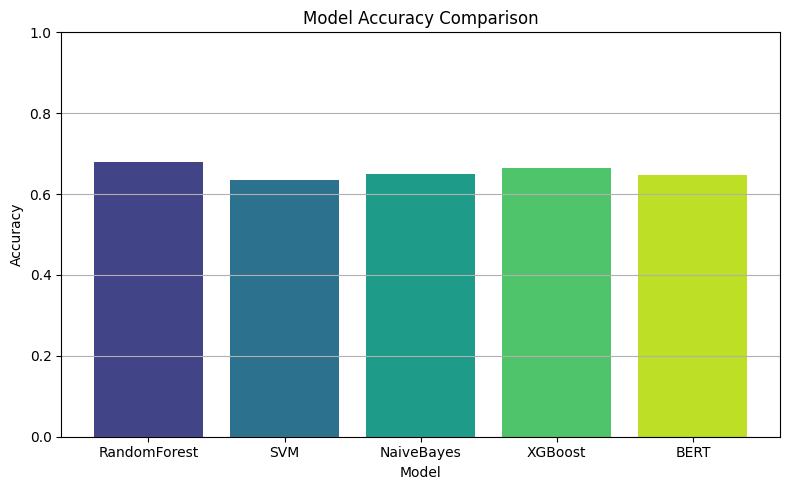

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, accuracy_score, f1_score
model_names = ["RandomForest", "SVM", "NaiveBayes", "XGBoost","BERT"]

all_model_preds = {
    name: preds 
    for name, preds in zip(model_names, y_preds)
}

y_true = np.array(y_test)
for model_name, preds in all_model_preds.items():
    preds = np.array(preds)

    df = pd.DataFrame({
        "y_true": y_true,
        "y_pred": preds
    })

    csv_name = f"{model_name}_predictions.csv"
    df.to_csv(csv_name, index=False)

    print(f"Saved: {csv_name}")
print("All predictions saved to CSV files.")
for model_name, preds in all_model_preds.items():
    preds = np.array(preds)

    report = classification_report(
        y_true,
        preds,
        digits=4
    )

    report_file = f"{model_name}_classification_report.txt"
    with open(report_file, "w") as f:
        f.write(report)

    print(f"\n===== {model_name} Classification Report =====")
    print(report)
    print(f"Saved: {report_file}")
model_scores = {}

for model_name, preds in all_model_preds.items():
    preds = np.array(preds)

    acc = accuracy_score(y_true, preds)
    f1_macro = f1_score(y_true, preds, average="macro")

    model_scores[model_name] = {
        "accuracy": acc,
        "f1_macro": f1_macro
    }

    print(f"{model_name} -> Accuracy: {acc:.4f}, F1-macro: {f1_macro:.4f}")
names = list(model_scores.keys())
accuracies = [model_scores[m]["accuracy"] for m in names]
cmap = plt.get_cmap("viridis")

# Normalize values between 0 and 1
colors = cmap(np.linspace(0.2, 0.9, len(accuracies)))
plt.figure(figsize=(8,5))
plt.bar(names, accuracies,color=colors)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


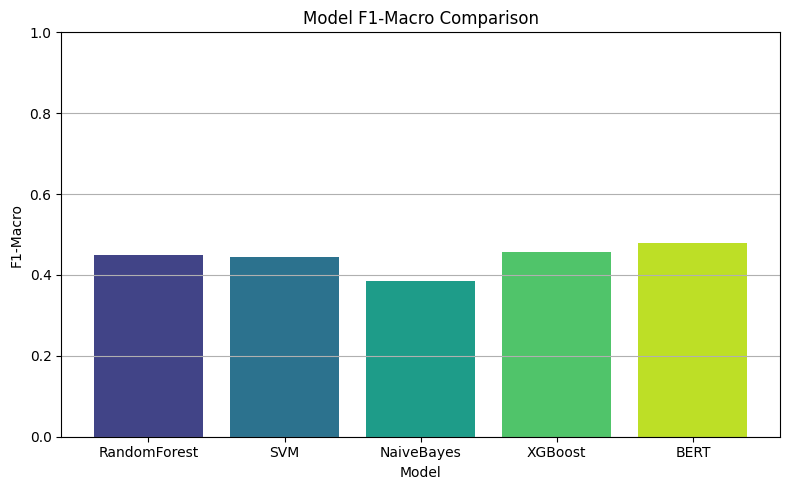

In [51]:
f1_scores = [model_scores[m]["f1_macro"] for m in names]
cmap = plt.get_cmap("viridis")

# Normalize values between 0 and 1
colors = cmap(np.linspace(0.2, 0.9, len(f1_scores)))
plt.figure(figsize=(8,5))
plt.bar(names, f1_scores,color=colors)
plt.title("Model F1-Macro Comparison")
plt.ylabel("F1-Macro")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [47]:
from sklearn.metrics import precision_score
import numpy as np
import matplotlib.pyplot as plt

# Convert once
y_true = np.array(y_true)

# Collect precision values
precision_per_class = {}    # {model: [p_class0, p_class1, ...]}

for model_name, preds in all_model_preds.items():
    preds = np.array(preds)
    # average=None gives precision for each class separately
    precisions = precision_score(y_true, preds, average=None, zero_division=0)
    precision_per_class[model_name] = precisions


<Figure size 1200x600 with 0 Axes>

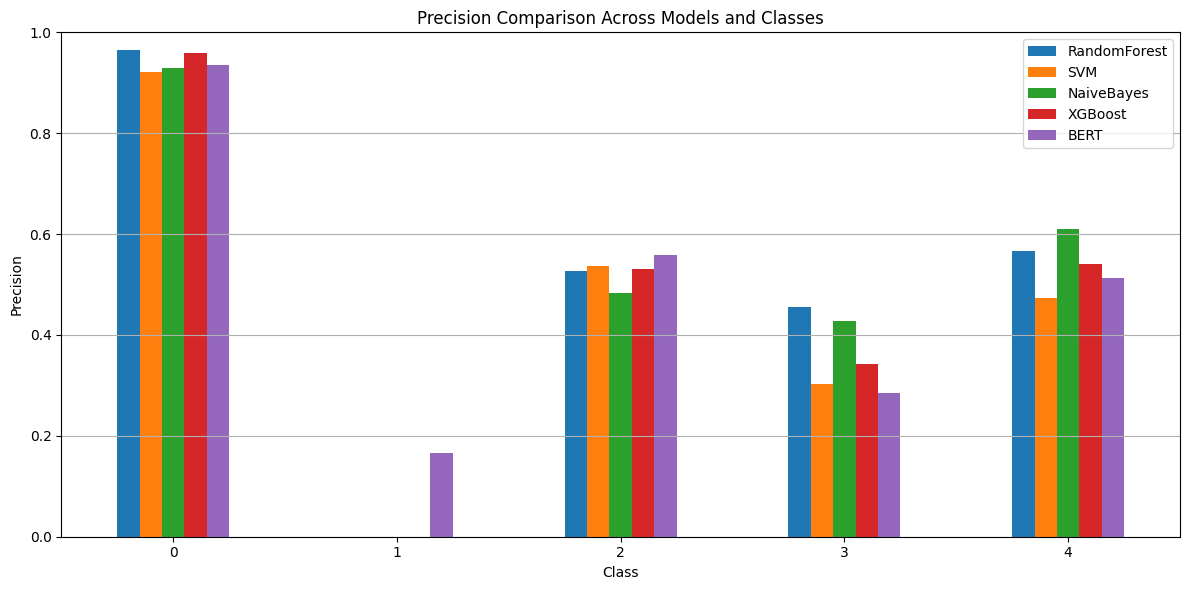

In [49]:
from sklearn.metrics import precision_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Convert to numpy
y_true = np.array(y_true)

# Compute precision per class for each model
precision_per_class = {}   # {model_name: [p_class0, p_class1, ...]}

for model_name, preds in all_model_preds.items():
    preds = np.array(preds)
    precisions = precision_score(
        y_true, preds, average=None, zero_division=0
    )
    precision_per_class[model_name] = precisions

# Convert to DataFrame for easy plotting
df = pd.DataFrame(precision_per_class)
df.index.name = "Class"

# Plot: ONE grouped bar chart
plt.figure(figsize=(12, 6))
df.plot(kind="bar", figsize=(12, 6))

plt.title("Precision Comparison Across Models and Classes")
plt.xlabel("Class")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
